In [ ]:
import torch as t
import numpy as np
import random

random.seed(0)
np.random.seed(0)
t.manual_seed(0)
t.cuda.manual_seed(0)
t.backends.cudnn.deterministic=True

In [ ]:
import torchvision.datasets

MNIST_train = torchvision.datasets.FashionMNIST('./', download = True, train = True)
MNIST_test = torchvision.datasets.FashionMNIST('./', download = True, train = False)

In [ ]:
X_train = MNIST_train.train_data
y_train = MNIST_train.train_labels
X_test = MNIST_test.test_data
y_test = MNIST_test.test_labels

/usr/local/lib/python3.10/dist-packages/torchvision/datasets/mnist.py:75: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")
/usr/local/lib/python3.10/dist-packages/torchvision/datasets/mnist.py:65: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.10/dist-packages/torchvision/datasets/mnist.py:80: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
/usr/local/lib/python3.10/dist-packages/torchvision/datasets/mnist.py:70: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


In [ ]:
X_train.dtype, y_train.dtype

(torch.uint8, torch.int64)

In [ ]:
X_train = X_train.float()
X_test = X_test.float()

In [ ]:
X_train.shape, X_test.shape

(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

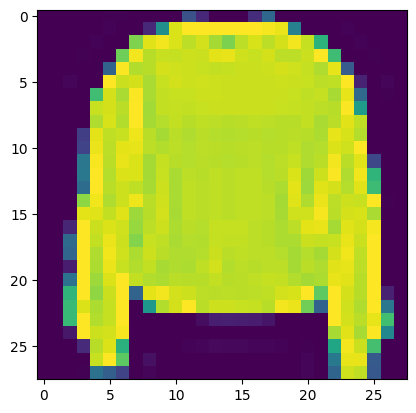

tensor(2)


In [ ]:
import matplotlib.pyplot as plt
plt.imshow(X_train[7, :, :])
plt.show()
print(y_train[7])

In [ ]:
y_train.unique()

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
X_train = X_train.reshape([-1, 28*28])
X_test = X_test.reshape([-1, 28*28])

print(X_train)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


In [ ]:
class MNISTnet(t.nn.Module):
  def __init__(self):
    super (MNISTnet, self).__init__()
    self.fc1 = t.nn.Linear(28*28, 500)
    self.act1 = t.nn.Tanh()
    self.fc2 = t.nn.Linear(500, 10)
    self.sm = t.nn.Softmax(dim=1)

  def forward(self, x):
    x = self.fc1(x)
    x = self.act1(x)
    x = self.fc2(x)
    return x


  def predict(self,x):
    with t.no_grad():
        x = self.forward(x)
        x = x.reshape(1, 10)
        x = self.sm(x)
        _, predicted = t.max(x, 1)
    return predicted.item()

net = MNISTnet()

In [ ]:
t.cuda.is_available()

True

In [ ]:
!nvidia-smi

Mon Mar 11 16:15:15 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   69C    P0              29W /  70W |    271MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
device = t.device('cuda:0' if t.cuda.is_available() else 'cpu')
net = net.to(device)

In [ ]:
#лосс функция
loss = t.nn.CrossEntropyLoss()

In [ ]:
def test_optim(opt, X_train, X_test, y_train, y_test):
    batch_size = 100   # размер батча
    epochs = 50   #количество эпох

    train_losses = []
    test_losses = []

    X_test = X_test.to(device)
    y_test = y_test.to(device)

    '''данные тренировочной выборки будем перекладывать на cuda по батчам'''
    for epoch in range(epochs):
        order = np.random.permutation(len(X_train))
        for start_index in range (0,len(X_train), batch_size):
            opt.zero_grad()
            batch_index = order[start_index:start_index+batch_size]

            X_batch = X_train[batch_index]
            y_batch = y_train[batch_index]

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = net.forward(X_batch)
            loss_val = loss(preds, y_batch)
            loss_val.backward()

            opt.step()

        train_losses.append(loss_val.item())
        test_preds = net.forward(X_test)
        test_loss = loss(test_preds, y_test).item()
        test_losses.append(test_loss)

    return test_losses

In [ ]:
opt = {}
test_losses = {}

Momentum

In [ ]:
opt["Momentum"] = t.optim.SGD(net.parameters(), lr = 0.001, momentum=0.9)
test_losses["Momentum"] = test_optim(opt["Momentum"], X_train, X_test, y_train, y_test)

AdaGrad

In [ ]:
opt["AdaGrad"] = t.optim.Adagrad(net.parameters(), lr = 0.001)
test_losses["AdaGrad"] = test_optim(opt["AdaGrad"], X_train, X_test, y_train, y_test)

RMSProp

In [ ]:
opt["RMSProp"] = t.optim.RMSprop(net.parameters(), lr = 0.001, weight_decay=0.01)
test_losses["RMSProp"] = test_optim(opt["RMSProp"], X_train, X_test, y_train, y_test)

Adam

In [ ]:
opt["Adam"] = t.optim.Adam(net.parameters(), lr = 0.001)
test_losses["Adam"] = test_optim(opt["Adam"], X_train, X_test, y_train, y_test)

AdaMax

In [ ]:
opt["AdaMax"] = t.optim.Adamax(net.parameters(), lr = 0.001)
test_losses["AdaMax"] = test_optim(opt["AdaMax"], X_train, X_test, y_train, y_test)

AdaDelta

In [ ]:
opt["AdaDelta"] = t.optim.Adadelta(net.parameters(), lr = 0.001)
test_losses["AdaDelta"] = test_optim(opt["AdaDelta"], X_train, X_test, y_train, y_test)

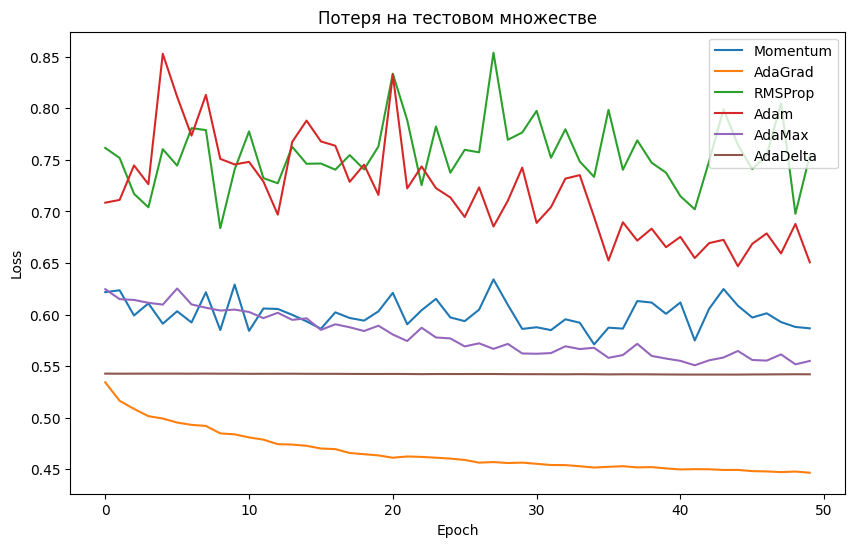

In [ ]:
plt.figure(figsize=(10,6))
for optim in test_losses.keys():
  plt.plot(test_losses[optim], label=optim)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Потеря на тестовом множестве")
plt.legend()
plt.show()